# Exploratory Data Analysis – World Happiness Report

**Course:** Programming for Artificial Intelligence and Data Science (P4AI-DS) 


**Assignment:** 1 - Exploratory Data Analysis (Tabular Data)


**Dataset:** Twitter financial news sentiment


**Source:** [Hunggingface - Twitter financial news sentiment](https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment)


In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from collections import Counter
import plotly.graph_objects as go
import re
import numpy as np
url = "https://huggingface.co/datasets/zeroshot/twitter-financial-news-sentiment/raw/main/sent_train.csv"
df = pd.read_csv(url)
copy_df = df
def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', '', text)
def handle_company(text):
    return re.sub(r'\$\w+', '<code>', text)
def clean_text(text):
    text = re.sub(r'<code>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
STOP_WORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he',
    'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's",
    'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because',
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all',
    'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not',
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will', 'just',
    'should', 'now', 'one', 'also'
])
def take_company(text):
    return re.findall(r'\$[A-Za-z]+', str(text))
df['text'] = df['text'].apply(remove_urls)
df['tickers'] = df['text'].apply(take_company)
df['text'] = df['text'].apply(handle_company)
df['text'] = df['text'].apply(lambda x: x.lower())
df['text'] = df['text'].apply(clean_text)
# df['text'] = df['text'].apply(nlp_using)
df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in STOP_WORDS])
)

print(df)

                                                   text  label       tickers
0               jpmorgan reels expectations beyond meat      0       [$BYND]
1     nomura points bookings weakness carnival royal...      0  [$CCL, $RCL]
2     cemex cut credit suisse jp morgan weak buildin...      0         [$CX]
3                            btig research cuts neutral      0        [$ESS]
4                     funko slides piper jaffray pt cut      0       [$FNKO]
...                                                 ...    ...           ...
9538  weeks gainers losers stoxx europe dec economy ...      2            []
9539  tupperware brands among consumer gainers unile...      2            []
9540  vtv therapeutics leads healthcare gainers myom...      2            []
9541                work xpo pyx amkr among hour movers      2            []
9542                     yndx qd oesx among tech movers      2            []

[9543 rows x 3 columns]


## 1. Dataset Overview

In [20]:
print("\n--- DATA OVERVIEW ---")
print("Training samples:", f"{len(df):,}")
print("Number of columns:", f"{len(df.columns)-1}")
print(f"Shape: {df.shape[0],df.shape[1]-1}\n")


--- DATA OVERVIEW ---
Training samples: 9,543
Number of columns: 2
Shape: (9543, 2)



## 2. Missing Values Analysis

In [21]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100)

missing_df = pd.DataFrame({
    'column': missing_counts[missing_counts > 0].index,
    'count': missing_counts[missing_counts > 0].values,
    'percentage': missing_pct[missing_counts > 0].values
}).sort_values('percentage', ascending=False)
if len(missing_df) > 0:
    print("Missing Values Summary:")
    print(missing_df)

    fig = go.Figure(data=[go.Bar(
        x=missing_df['column'],
        y=missing_df['percentage'],
        marker_color='#f093fb',
        text=[f"{p:.2f}%" for p in missing_df['percentage']],
        textposition='outside'
    )])

    fig.update_layout(
        title='Missing Values by Feature (%)',
        xaxis_title='Features',
        yaxis_title='Missing Percentage',
        width=800,
        height=400
    )

    fig.show()
    print("\n💡 Recommendations:")
    for _, row in missing_df.iterrows():
        col, pct = row['column'], row['percentage']
        if pct > 50:
            print(f"  {col}: {pct:.1f}% missing → Consider dropping")
        elif pct > 5:
            print(f"  {col}: {pct:.1f}% missing → Use advanced imputation (KNN, iterative)")
        else:
            print(f"  {col}: {pct:.1f}% missing → Simple imputation (mode/median)")
else:
    print("✅ Dataset is clean. No missing values reported.")

✅ Dataset is clean. No missing values reported.


## 3. Category Distribution

       Frequency  Ratio (%)
label                      
0           1442  15.110552
1           1923  20.150896
2           6178  64.738552

--- CATEGORY DISTRIBUTION ---


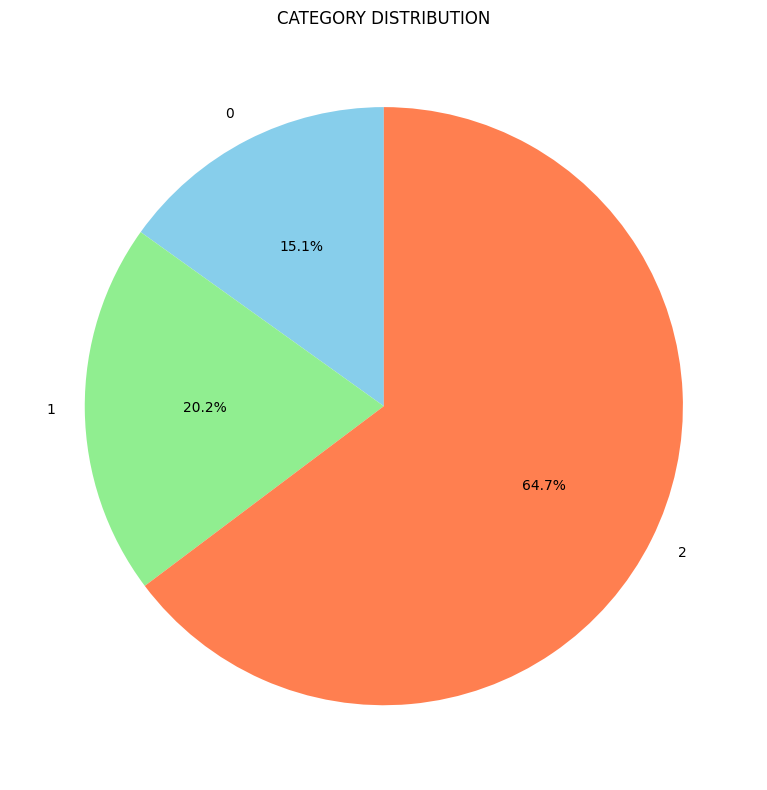

In [22]:
counts = df['label'].value_counts().sort_index()
table = counts.to_frame(name='Frequency')
table['Ratio (%)'] = (counts / counts.sum()) * 100
print(table)
print("\n--- CATEGORY DISTRIBUTION ---")
fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
table['Ratio (%)'],
labels=table.index,
autopct='%1.1f%%',
startangle=90,
colors=['skyblue', 'lightgreen', 'coral']
)

ax.set_title("CATEGORY DISTRIBUTION")

plt.tight_layout()
plt.show()

## 4 Wordcount Distribution

In [23]:

df['word_count'] = df['text'].apply(lambda x: len(x.split()))
   
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: {df['word_count'].quantile(p/100):.0f}")
bins = np.arange(0, df['word_count'].max() + 5, 5)
hist, bin_edges = np.histogram(df['word_count'], bins=bins)
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(hist))]
 # Print statistics
print(f"Mean: {df['word_count'].mean():.2f}")
print(f"Median: {df['word_count'].median():.2f}")
print(f"Min: {df['word_count'].min()}")
print(f"Max: {df['word_count'].max()}")

print("\nPercentiles:")
fig = go.Figure(data=[go.Bar(
x=bin_labels,
y=hist,
text=hist,
textposition='outside'
)])

fig.update_layout(
title='Word Count Distribution (sent_train)',
xaxis_title='Word Count Ranges',
yaxis_title='Number of Samples',
width=900,
height=600,
showlegend=False,
xaxis={'tickangle': 45}
)






  25th: 6
  50th: 8
  75th: 10
  90th: 12
  95th: 13
  99th: 14
Mean: 7.98
Median: 8.00
Min: 0
Max: 27

Percentiles:


## 5 Text Length Distribution

In [24]:
df['char_count'] = df['text'].str.len()
bins = np.arange(0, df['char_count'].max() + 20, 20)

hist, bin_edges = np.histogram(df['char_count'], bins=bins)

    # Format labels
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(hist))]
    # Statistics
print(f"Mean: {df['char_count'].mean():.2f}")
print(f"Median: {df['char_count'].median():.2f}")
print(f"Min: {df['char_count'].min()}")
print(f"Max: {df['char_count'].max()}")

    # Average word length
avg_word_length = df['char_count'].sum() / df['text'].str.split().str.len().sum()
print(f"Average word length: {avg_word_length:.2f} characters")

    # Create histogram
fig = go.Figure(data=[go.Bar(
x=bin_labels,
y=hist,
text=hist,
textposition='outside'
)])

fig.update_layout(
title='Character Count Distribution (sent_train)',
xaxis_title='Character Count Ranges',
yaxis_title='Number of Samples',
width=900,
height=600,
showlegend=False,
xaxis={'tickangle': 45}
)





Mean: 56.39
Median: 55.00
Min: 0
Max: 174
Average word length: 7.07 characters


## 6 Tickers Ditribution

In [25]:
all_tickers = [t for sublist in df['tickers'] for t in sublist]
ticker_freq = Counter(all_tickers)
top_tickers = ticker_freq.most_common(5)
tickers_x = [t[0] for t in top_tickers]
tickers_y = [t[1] for t in top_tickers]

fig = go.Figure(data=[go.Bar(
x=tickers_x,
y=tickers_y,
textposition='outside'
)])

fig.update_layout(
title="Top 5 Most Mentioned Tickers",
xaxis_title="Ticker",
yaxis_title="Frequency",
width=800,
height=600
)


## 7 TF - IDF Top Terms by Category

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
label_name = {0: "0", 1: "1", 2: "2"}
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df['text'])
feature_names = vectorizer.get_feature_names_out()

for label_to_plot in [0,1, 2]:
    cat_indices = df[df['label'] == label_to_plot].index
    cat_tfidf = tfidf_matrix[cat_indices]
    mean_scores = np.array(cat_tfidf.mean(axis=0)).flatten()

    top_indices = mean_scores.argsort()[-20:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = [mean_scores[i] for i in top_indices]

    fig = go.Figure(data=[go.Bar(
        x=top_scores,
        y=top_words,
        orientation='h',
        marker_color='#FF4B4B' if label_to_plot == 0 else ('#00CC96' if label_to_plot == 1 else '#636EFA'),
        text=[f'{score:.4f}' for score in top_scores],
        textposition='outside')])

    fig.update_layout(
        title=f'Top 20 TF-IDF Words in {label_name[label_to_plot]}',
        xaxis_title='Average TF-IDF Score',
        yaxis_title='Words',
        width=800,
        height=600,
        yaxis={'autorange': 'reversed'})
    fig.show()

## 8 N-gram Analysis

In [27]:
label_name = {0: "0", 1: "1", 2: "2"}
vectorizer = TfidfVectorizer(
            ngram_range=(2, 2), 
            max_features=50,
    )

for label_to_plot in [0,1, 2]:
    cat_df = df[df['label'] == label_to_plot]

    combined_text = ' '.join(cat_df['text'].values)


       
    tfidf_matrix = vectorizer.fit_transform([combined_text])

    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.toarray()[0]

    top_indices = tfidf_scores.argsort()[-15:][::-1]
    top_bigrams = [feature_names[i] for i in top_indices]
    top_scores = [tfidf_scores[i] for i in top_indices]

    bar_color = '#FF4B4B' if label_to_plot == 0 else ('#00CC96' if label_to_plot == 1 else '#636EFA')

    fig = go.Figure(data=[go.Bar(
        x=top_scores,
        y=top_bigrams,
        orientation='h',
        marker_color=bar_color,
        text=[f'{score:.4f}' for score in top_scores],
        textposition='outside')])

    fig.update_layout(
        title=f'Top 15 Bigrams in {label_name[label_to_plot]} (TF-IDF)',
        xaxis_title='TF-IDF Score',
        yaxis_title='Bigrams',
        width=900,
        height=600,
        yaxis={'autorange': 'reversed'})

    fig.show()

## 9 Category Similarity Matrix

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
label_names = {0: '0', 1: '1', 2: '2'}
categories = [0, 1, 2]
category_labels = [label_names[cat] for cat in categories]

vectorizer = TfidfVectorizer(max_features=5000, stop_words=list(STOP_WORDS))
tfidf_matrix = vectorizer.fit_transform(df['text'])

n_cats = len(categories)
similarity_matrix = np.zeros((n_cats, n_cats))

for i, cat1 in enumerate(categories):
    cat1_indices = df[df['label'] == cat1].index
    cat1_vectors = tfidf_matrix[cat1_indices]
    
for j, cat2 in enumerate(categories):
    cat2_indices = df[df['label'] == cat2].index
    cat2_vectors = tfidf_matrix[cat2_indices]

    pairwise_sim = cosine_similarity(cat1_vectors, cat2_vectors)

    similarity_matrix[i, j] = np.mean(pairwise_sim)
fig = go.Figure(data=go.Heatmap(
    z=similarity_matrix,
    x=category_labels,
    y=category_labels,
    colorscale='Teal', 
    text=similarity_matrix,
    texttemplate='%{text:.4f}',
    textfont={"size": 14},
    colorbar=dict(title="Similarity")))

fig.update_layout(
    title='Category Similarity Matrix (Cosine Similarity)',
    xaxis_title='Category',
    yaxis_title='Category',
    width=800,
    height=600,
    yaxis={'autorange': 'reversed'})

fig.show()

c:\Users\tue26\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 're', 've'] not in stop_words.
  warnings.warn(


## 10 Text Statistics

In [29]:
word_counts = copy_df['text'].apply(lambda x: len(str(x).split()))
max_words = word_counts.max()
min_words = word_counts.min()
mean_words = word_counts.mean()
std_words = word_counts.std()

# 3. Print the results clearly
print("--- Text Length Statistics (Word Count) ---")
print(f"Max words          : {max_words}")
print(f"Min words          : {min_words}")
print(f"Mean (Avg) words   : {mean_words:.2f}")
print(f"Standard Deviation : {std_words:.2f}")

--- Text Length Statistics (Word Count) ---
Max words          : 27
Min words          : 0
Mean (Avg) words   : 7.98
Standard Deviation : 2.78


# Dataset Characteristics


**Imbalanced Dataset:** The categories are highly skewed. The Neutral class (Label 2) dominates the dataset at approximately 64.7%, while Positive (Label 1) accounts for 20.2% and Negative (Label 0) makes up only 15.1%. This severe imbalance means we will likely need to use class weights or resampling techniques during model training to prevent bias.


**Article Length:** The texts are extremely short, averaging only about 12 words per entry (with a maximum of 32 words). This reflects a "micro-blogging" or rapid-fire news headline format, typical of Twitter or StockTwits.


**Vocabulary:** The vocabulary is highly specialized for finance and social media. It heavily features "Cashtags" (stock tickers preceded by $, e.g., $TSLA), financial shorthand (EPS, PT, downgrades, bullish), and web URLs.


**Quality:** The raw dataset is 100% complete with zero missing values. However, because the text is sourced from social media and quick headlines, it features informal grammar, abbreviations, and sentence fragments rather than professionally structured paragraphs.


# Data Processing Notes


**Raw Statistics:** Initial metrics (like total word counts and sentence lengths) were calculated using the raw, uncleaned text. This includes all grammatical connectors (the, and, in), special characters, stock tickers, and URLs.


**Vocabulary Analysis:** Advanced feature extraction (such as TF-IDF and Bigram frequencies) was only performed AFTER aggressive text cleaning. This cleaning process involved using Regular Expressions (Regex) to strip out all https://... links and $TICKER symbols.

**Stop Words Removed:** In addition to standard English stop words (the, is, at, which, etc.), we removed a custom list of financial and social media noise words (e.g., https, co, rt, stock, market, shares, company, said, just).

**Why Mixed Approach:** We kept the raw statistics to understand the true physical shape of the data, which helps us set exact parameters for machine learning models (e.g., setting the max_length = 35 for a Deep Learning/BERT model)